# Binary 64x64 Topology Optimization Pipeline

This notebook orchestrates the modular `16 -> 32 -> 64` binary search pipeline implemented in `gen_rl/`.
It replaces the old monolithic GA/FEM/RL cells with a staged search, cached evaluator, boundary-only refinement,
and optional `MaskablePPO` refinement when the RL stack is available.


In [1]:
from __future__ import annotations

import json
import sys
from importlib.util import find_spec
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "gigala").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing the gigala package.")

from gigala.topology.topology_optimiz.gen_rl import ProblemConfig, run_multistage_search
from gigala.topology.topology_optimiz.gen_rl.refine_env import make_refine_env

HAS_GYM = find_spec("gymnasium") is not None
HAS_SB3 = find_spec("stable_baselines3") is not None
HAS_SB3_CONTRIB = find_spec("sb3_contrib") is not None
HAS_MASKABLE_RL = HAS_GYM and HAS_SB3 and HAS_SB3_CONTRIB

print(json.dumps({
#     "repo_root": str(REPO_ROOT),
    "has_gymnasium": HAS_GYM,
    "has_stable_baselines3": HAS_SB3,
    "has_sb3_contrib": HAS_SB3_CONTRIB,
    "maskable_rl_ready": HAS_MASKABLE_RL,
}, indent=2))


{
  "has_gymnasium": true,
  "has_stable_baselines3": true,
  "has_sb3_contrib": true,
  "maskable_rl_ready": true
}


In [2]:
HAS_MASKABLE_RL

True

In [3]:
from torch.distributions import Distribution
Distribution.set_default_validate_args(False)

In [4]:
config = ProblemConfig(
    resolution=32,
    volume_target=0.55,
    solver_backend="scipy",
    runtime_budget_hours=3.0,
    enable_rl=HAS_MASKABLE_RL,
    rl_total_timesteps=500_000,
    coarse_population=128,
    coarse_generations=250,
    coarse_elite_count=16,
    stage32_top_k=8,
    stage64_top_k=2,
    local_search_steps32=48,
    local_search_steps64=96,
    max_full_evals=20_000,
    max_rl_full_evals=5_000,
)
config


ProblemConfig(resolution=32, volume_target=0.55, load_case='cantilever', solver_backend='scipy', runtime_budget_hours=3.0, random_seed=42, coarse_population=128, coarse_generations=250, coarse_elite_count=16, stage32_top_k=8, stage64_top_k=2, frontier_width=2, local_search_steps32=48, local_search_steps64=96, full_eval_every=16, max_episode_steps=256, enable_rl=True, rl_device='auto', rl_total_timesteps=500000, max_full_evals=20000, max_rl_full_evals=5000, density_floor=0.0001, volume_tolerance=0.2, smoothness_weight=0.1, island_weight=0.35, volume_weight=1.0, one_island_bonus=0.05, invalid_penalty=1000000000000.0, proxy_filter_quantile=0.35, notes={})

In [5]:
artifacts = run_multistage_search(config)
artifacts

StageArtifacts(coarse16=array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 0, 0, 1],
       [1, 1, 1, ..., 0, 0, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], dtype=uint8), refined32=None, refined64=None, metrics={'coarse16': {'fidelity': 'proxy32', 'resolution': 32, 'compliance': 23.30884924818494, 'score': 23.31567801261312, 'volume_fraction': 0.5693359375, 'smoothness': 317, 'islands': 1, 'fea_performed': True, 'cache_hit': True, 'passed_filters': True, 'invalid_reason': None}}, fea_counts={'proxy16': 0.0, 'proxy32': 25751.0, 'full64': 0.0, 'cache_hits': 1796.0, 'cache_size': 25769.0}, runtime=489.2195029258728, warnings=[])

In [6]:
summary = {
    "runtime_sec": round(artifacts.runtime, 2),
    "fea_counts": artifacts.fea_counts,
    "warnings": artifacts.warnings,
    "stage_metrics": artifacts.metrics,
}
print(json.dumps(summary, indent=2))

{
  "runtime_sec": 489.22,
  "fea_counts": {
    "proxy16": 0.0,
    "proxy32": 25751.0,
    "full64": 0.0,
    "cache_hits": 1796.0,
    "cache_size": 25769.0
  },
  "warnings": [],
  "stage_metrics": {
    "coarse16": {
      "fidelity": "proxy32",
      "resolution": 32,
      "compliance": 23.30884924818494,
      "score": 23.31567801261312,
      "volume_fraction": 0.5693359375,
      "smoothness": 317,
      "islands": 1,
      "fea_performed": true,
      "cache_hit": true,
      "passed_filters": true,
      "invalid_reason": null
    }
  }
}


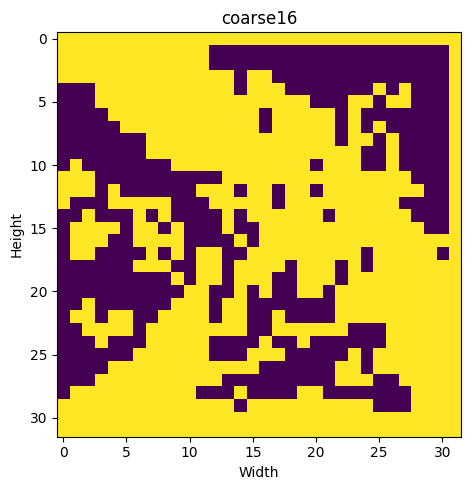

In [7]:
def show_stage_masks(stage_artifacts):
    masks = [
        ("coarse16", stage_artifacts.coarse16),
        ("refined32", stage_artifacts.refined32),
        ("refined64", stage_artifacts.refined64),
    ]
    available = [(name, mask) for name, mask in masks if mask is not None]
    
    fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 5))
    if len(available) == 1:
        axes = [axes]
        
    for axis, (name, mask) in zip(axes, available):
        axis.imshow(mask, cmap="viridis")
        axis.set_title(name)
        # axis.axis("off")  <-- Удаляем или комментируем эту строку
        
        # Добавляем подписи осей для наглядности масштаба
        axis.set_xlabel('Width')
        axis.set_ylabel('Height')
        
    plt.tight_layout()
    plt.show()


show_stage_masks(artifacts)

## Optional: Inspect the RL Refinement Environment

The staged pipeline already runs the pre-RL search. If `sb3-contrib` and `gymnasium` are installed,
the final stage can be inspected directly through `make_refine_env`.


In [10]:
if HAS_MASKABLE_RL and artifacts.refined64 is not None:
    env = make_refine_env(artifacts.refined64, config)
    obs, info = env.reset()
    print("observation shape:", obs.shape)
    print("valid actions:", int(env.action_masks().sum()), "out of", env.action_space.n)
else:
    print("Maskable RL stack is not available; skipping env inspection.")

Maskable RL stack is not available; skipping env inspection.
